# Cropping the Mesh to the Grid Nodes' Convex Hull

When working with irregular or non-rectangular spatial datasets (e.g., circular domains, regional boundaries), the standard rectilinear mesh layout will generate nodes that fill the entire bounding box, leading to "dead space" in the corners. 

You can pass `crop_to_grid_nodes_convex_hull=True` inside `mesh_layout_kwargs` to apply a spatial pruning step. This computes the Delaunay triangulation of the input grid coordinates' convex hull and removes any mesh nodes that fall outside the actual data perimeter.

*Note: Currently, this feature is supported for `keisler` (flat) and `oskarsson_hierarchical` graphs, but not `graphcast` (flat_multiscale) as it breaks the index-based stride assumptions of the multiscale generator.*

2026-07-13 09:27:19.034 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:219 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.
2026-07-13 09:27:19.193 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:219 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


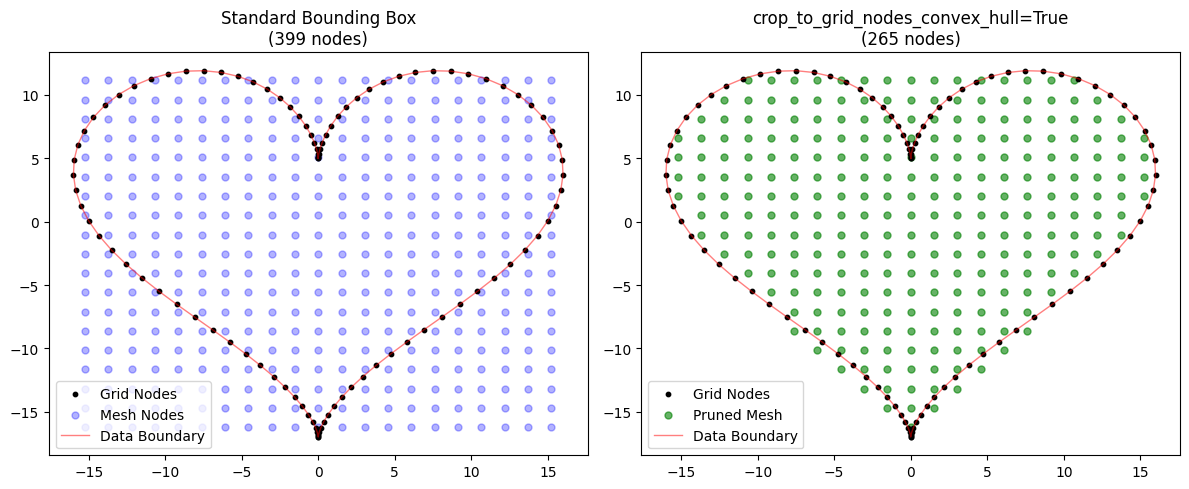

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from weather_model_graphs.create.archetype import create_keisler_graph

# 1. Create irregular data (a heart shape) - These are our Grid Nodes
t = np.linspace(0, 2 * np.pi, 100)
x = 16 * np.sin(t) ** 3
y = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
xy_data = np.column_stack((x, y))

# 2. Generate standard mesh (Before)
g_standard = create_keisler_graph(xy_data, mesh_node_distance=1.5)
pos_standard = np.array(
    [
        data["pos"]
        for _, data in g_standard.nodes(data=True)
        if data.get("type") == "mesh"
    ]
)

# 3. Generate cropped mesh (After)
g_cropped = create_keisler_graph(
    xy_data,
    mesh_node_distance=1.5,
    crop_to_grid_nodes_convex_hull=True,
)
pos_cropped = np.array(
    [
        data["pos"]
        for _, data in g_cropped.nodes(data=True)
        if data.get("type") == "mesh"
    ]
)

# 4. Plot the results side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Standard Bounding Box
ax1.scatter(xy_data[:, 0], xy_data[:, 1], c="black", s=10, label="Grid Nodes", zorder=2)
ax1.scatter(
    pos_standard[:, 0],
    pos_standard[:, 1],
    c="blue",
    s=25,
    alpha=0.3,
    label="Mesh Nodes",
    zorder=1,
)
ax1.plot(
    xy_data[:, 0], xy_data[:, 1], c="red", linewidth=1, alpha=0.5, label="Data Boundary"
)
ax1.set_title(f"Standard Bounding Box\n({len(pos_standard)} nodes)")
ax1.legend()

# Convex Hull Cropped
ax2.scatter(xy_data[:, 0], xy_data[:, 1], c="black", s=10, label="Grid Nodes", zorder=2)
ax2.scatter(
    pos_cropped[:, 0],
    pos_cropped[:, 1],
    c="green",
    s=25,
    alpha=0.6,
    label="Pruned Mesh",
    zorder=1,
)
ax2.plot(
    xy_data[:, 0], xy_data[:, 1], c="red", linewidth=1, alpha=0.5, label="Data Boundary"
)
ax2.set_title(f"crop_to_grid_nodes_convex_hull=True\n({len(pos_cropped)} nodes)")
ax2.legend()

plt.tight_layout()
plt.show()